# Model simulations: EVM – Equal Variance Model (Figure 3)

Standard SDT observer with equal belief SDs (σ<sub>high</sub> = σ<sub>low</sub> = 1) in both frames. Confidence = |LLR|.

**Generative process** (Methods, Model simulations): on each trial the side with high evidence is drawn from Bernoulli(0.5); evidence for each option is drawn from N(1, 1) (high-evidence side) or N(0, 1) (low-evidence side). The observer computes the log-likelihood ratio (LLR) that ⟨right, left⟩ = ⟨high, low⟩ under its belief distributions (μ<sub>low</sub> = 0, μ<sub>high</sub> = 1) and chooses right if LLR ≥ 0 in the high-evidence frame, or if LLR ≤ 0 in the low-evidence frame.

There are no data and no free parameters: `pm.sample` draws simulated trials from this generative model.

**Figure 3 panels** (per frame): A – choice and confidence as a function of ΔEvidence; B – confidence ~ chosen + unchosen evidence; D – confidence over binned left/right evidence; C (end of notebook) – β<sub>chosen</sub> + β<sub>unchosen</sub> over 100 repeated simulations.

In [1]:
import pymc as pm
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.core.pylabtools import figsize
import warnings
warnings.filterwarnings("ignore")
from scipy import stats
import seaborn as sns
import statsmodels.formula.api as sm
import  pytensor.tensor as pt

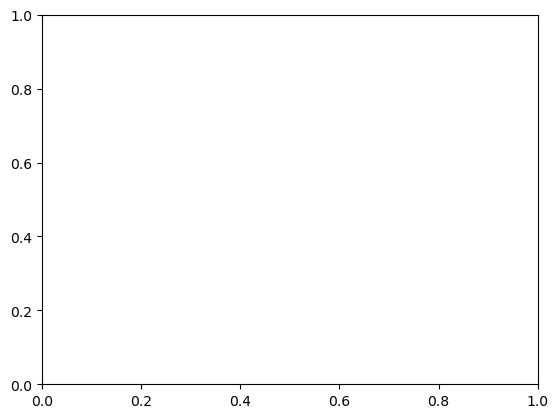

In [2]:
# Plotting helpers shared across notebooks; serif font for figures
import functionsSims as fs
from matplotlib import rcParams
rcParams['font.family'] = 'serif'

In [5]:
# Avoids an OpenMP duplicate-library error on some macOS setups
import os
os.environ['KMP_DUPLICATE_LIB_OK']='True'

In [10]:
# Z-score a column (across all rows, or within each level of part_def)
def z_score1(data_all,z_score_var, part_def = 0):
    z_matrix=[]
    z_matrix_aux=[]
    
    if part_def==0:
        z_matrix = (data_all[z_score_var] - data_all[z_score_var].mean())/ data_all[z_score_var].std()
    else:
        for i in (data_all[part_def].unique()):
            Choicedata = data_all.loc[data_all[part_def] == i]    
        
            pX_A= pd.to_numeric(Choicedata[z_score_var]) 
            pX_zA= (pX_A - np.mean(pX_A))/np.std(pX_A)
    
            z_matrix_aux= pX_zA.values
        
            for  j in range(len(z_matrix_aux)):    
                z_matrix.append(z_matrix_aux[j])
    return z_matrix

## High-evidence frame (choose the option with more evidence)

In [14]:
# Observer's belief distributions: means (low, high) and SDs (low, high)
mu = [0,1]
sigma = [1,1]

In [15]:
with pm.Model() as model_peb1:
    # Side with high evidence (0: left, 1: right)
    truDir = pm.Bernoulli("truDir", 0.5) 
    # Evidence for each option: mean 1 for the high-evidence side, 0 for the other (SD 1)
    lEnergy = pm.Normal('lEnergy', mu = 1 - truDir, sigma = 1)  # generative SD (not the observer's belief SD)
    rEnergy = pm.Normal('rEnergy', mu = truDir, sigma = 1)

    # Log-likelihood ratio that <right, left> = <high, low> under the observer's belief distributions (mu, sigma)
    LLR = pm.Deterministic('LLR',  pt.log(1/(sigma[1] * pt.sqrt(2 * np.pi))*pt.exp(-pt.power(rEnergy - mu[1] , 2.) / (2 * pt.power(sigma[1], 2.)))) - 
                                   pt.log(1/(sigma[0] * pt.sqrt(2 * np.pi))*pt.exp(-pt.power(rEnergy - mu[0] , 2.) / (2 * pt.power(sigma[0], 2.)))) + 
                                   pt.log(1/(sigma[0] * pt.sqrt(2 * np.pi))*pt.exp(-pt.power(lEnergy - mu[0] , 2.) / (2 * pt.power(sigma[0], 2.)))) -
                                   pt.log(1/(sigma[1] * pt.sqrt(2 * np.pi))*pt.exp(-pt.power(lEnergy - mu[1] , 2.) / (2 * pt.power(sigma[1], 2.))))  )
  
    # High-evidence frame: choose right (1) if LLR >= 0
    cho = pm.math.switch(LLR>=0, 1, 0)
    choice = pm.Deterministic('choice',cho)
    
    # Confidence = |LLR|
    conf = pm.Deterministic('conf',abs(LLR))
    # Draw simulated trials from the generative model (no observed data)
    trace = pm.sample(2000, chains = 1)

Sequential sampling (1 chains in 1 job)
CompoundStep
>BinaryGibbsMetropolis: [truDir]
>NUTS: [lEnergy, rEnergy]


Sampling 1 chain for 1_000 tune and 2_000 draw iterations (1_000 + 2_000 draws total) took 2 seconds.


In [18]:
# Simulated trials (choice, confidence, evidence) from the sampled trace
ppc = pm.sample_posterior_predictive(trace, model=model_peb1, var_names = ['choice','truDir','LLR','conf','lEnergy','rEnergy'])

Sampling: [lEnergy, rEnergy, truDir]


In [19]:
# Collect simulated trials: evidence, choice, confidence, chosen/unchosen evidence (z-scored for regressions)
posterior_df = pd.DataFrame()

posterior_df['choice'] = ppc.posterior_predictive['choice'].values[0]

posterior_df['energy_l'] = ppc.posterior_predictive['lEnergy'].values[0]

posterior_df['energy_r'] = ppc.posterior_predictive['rEnergy'].values[0]
posterior_df['conf'] = ppc.posterior_predictive['conf'].values[0]
posterior_df['truDir'] = ppc.posterior_predictive['truDir'].values[0]
posterior_df['d_energy'] = ppc.posterior_predictive['rEnergy'].values[0] - ppc.posterior_predictive['lEnergy'].values[0]
posterior_df['abs_d_energy'] = abs(ppc.posterior_predictive['rEnergy'].values[0] - ppc.posterior_predictive['lEnergy'].values[0])
posterior_df['sum_energy'] = ppc.posterior_predictive['rEnergy'].values[0] + ppc.posterior_predictive['lEnergy'].values[0]
posterior_df['correct'] = ppc.posterior_predictive['truDir'].values[0] == ppc.posterior_predictive['choice'].values[0]
posterior_df['energy_c'] = posterior_df.apply(lambda row: row.energy_r if row.choice==1 else row.energy_l, axis=1)
posterior_df['energy_u'] = posterior_df.apply(lambda row: row.energy_l if row.choice==1 else row.energy_r, axis=1)

posterior_df['z_d_energy'] = z_score1(posterior_df,'d_energy')
posterior_df['z_abs_d_energy'] = z_score1(posterior_df,'abs_d_energy')
posterior_df['z_sum_energy'] = z_score1(posterior_df,'sum_energy')
posterior_df['z_conf'] = z_score1(posterior_df,'conf')
posterior_df['z_energy_c'] = z_score1(posterior_df,'energy_c')
posterior_df['z_energy_u'] = z_score1(posterior_df,'energy_u')

bin_num = 2
# Median split of confidence
posterior_df['conf_split'] =  pd.to_numeric(pd.qcut(posterior_df["z_conf"].values, bin_num , labels=range(bin_num)))

Low measure coef [[201.36767308]]


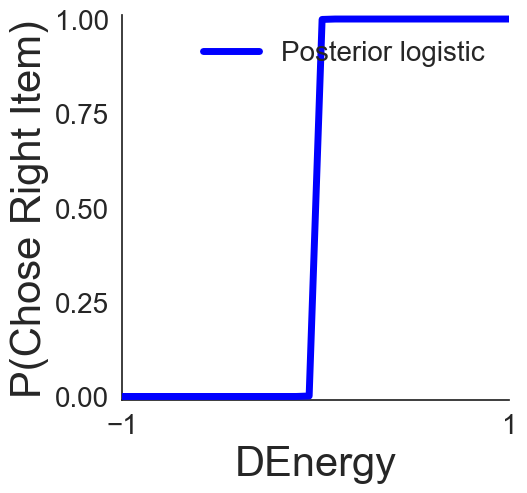

In [20]:
# P(choose right) as a function of ΔEvidence
fs.logisticplot_simpl ('Posterior logistic', posterior_df, xaxis='d_energy', yaxis='choice', ylab='P(Chose Right Item)', xlab='DEnergy',
                  modlowcol='blue', title='empty',xlim = [-1,1])

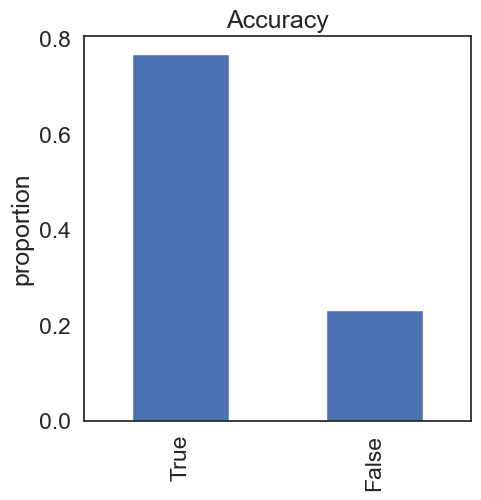

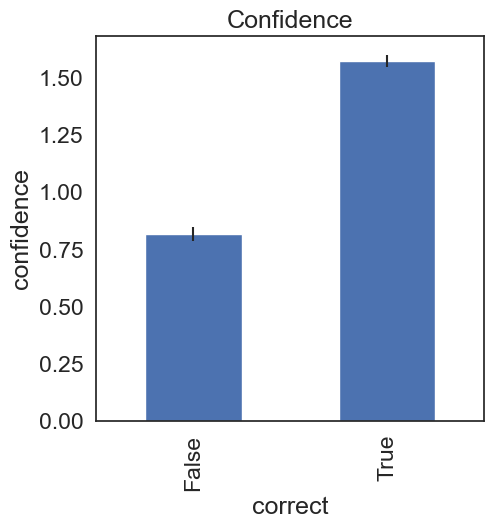

In [21]:
# Accuracy and confidence for correct vs error trials
posterior_df['correct'].value_counts(normalize=1,sort=0).plot(kind='bar',title='Accuracy')
plt.ylabel('proportion')
plt.show()

posterior_df.groupby('correct').mean()['conf'].plot(kind='bar',title='Confidence', 
                                                     yerr=posterior_df.groupby('correct').sem()['conf'])
plt.ylabel('confidence')
plt.show()

In [22]:
# Font sizes for the figures below
font_size = 22
font_size_l = 18

Correlation of confidence with chosen :  0.61 , p =  0.00 , unchosen : -0.59 , p =  0.00


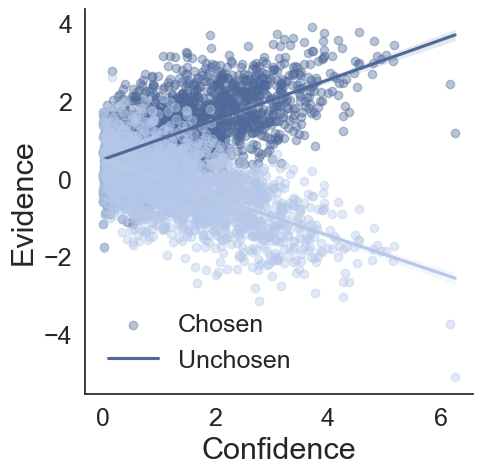

In [23]:
# Confidence vs chosen / unchosen evidence (Pearson correlations printed)
figsize(5, 5)
ax1 = sns.regplot(x="conf", y='energy_c',data=posterior_df,color='#4F6A9A',scatter_kws={'alpha':0.4})
sns.regplot(x="conf", y='energy_u',data=posterior_df,ax=ax1,color='#B5C8E9',scatter_kws={'alpha':0.4})
plt.ylabel("Evidence",fontsize = font_size)
plt.xlabel("Confidence",fontsize = font_size)
ax1.legend(labels=['Chosen', 'Unchosen'],fontsize = font_size_l,frameon = False)
plt.yticks(fontsize = font_size_l)
plt.xticks(fontsize = font_size_l)
sns.despine()

pcorr_cho = stats.pearsonr(posterior_df.conf.values, posterior_df.energy_c.values)
pcorr_uncho = stats.pearsonr(posterior_df.conf.values, posterior_df.energy_u.values)

print("Correlation of confidence with chosen : % .2f , p = % .2f , unchosen : % .2f , p = % .2f" %\
  (pcorr_cho[0],pcorr_cho[1],pcorr_uncho[0],pcorr_uncho[1])) 

Low measure coef [[590.95444581]]
High measure coef [[10.3048246]]


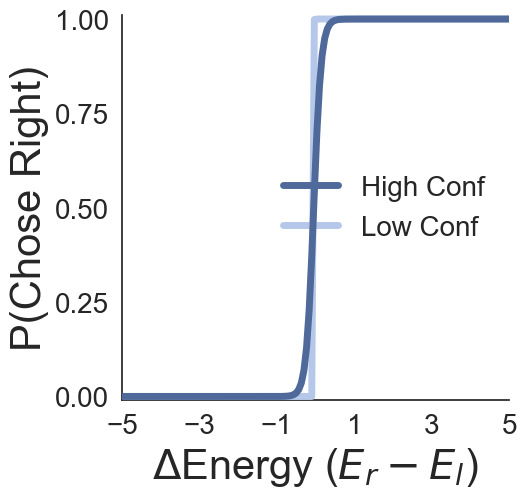

In [27]:
# Choice curves split by high / low confidence
fs.logisticplot_LowHigh ('conf_split', 'High Conf', 'Low Conf', posterior_df, xaxis='z_d_energy', yaxis='choice', ylab='P(Chose Right)', xlab='$\Delta$Energy ($E_{r}- E_{l}$)',
                 modhighcol='#4F6A9A', modlowcol='#B5C8E9', xlim = [-5,5])

Low measure coef [[511.88704076]]


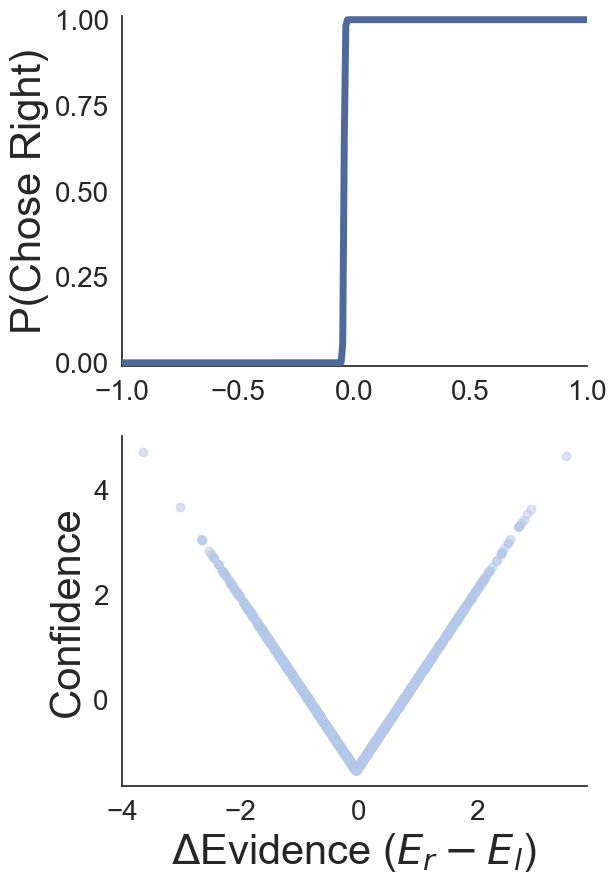

In [28]:
# Panel A: choice (top) and confidence (bottom) as a function of ΔEvidence
figModel, axModel = plt.subplots(figsize=(6, 10))

sub1 = plt.subplot(211)
fs.logisticplot_simpl_sims ('Posterior logistic', posterior_df, xaxis='z_d_energy', yaxis='choice', ylab='P(Chose Right)', xlab='',
                  modlowcol='#4F6A9A', title='empty',xlim = [-1,1],x_test_lim = 1, sub = sub1)
sub2 = plt.subplot(212)
sub2 = plt.scatter(posterior_df['z_d_energy'].values, posterior_df['z_conf'].values, c="#B5C8E9", alpha=0.5,
            label="Model")
plt.tick_params(axis='both', which='major', labelsize=20)
plt.ylabel ('Confidence',size=30)
plt.xlabel( '$\Delta$Evidence ($E_{r}- E_{l}$)',size=30)

sns.despine()

------------Simulations regression, conf -> chosen + unchosen ------------------ 
                            OLS Regression Results                            
Dep. Variable:                 z_conf   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                  1.000
Method:                 Least Squares   F-statistic:                 2.717e+33
Date:                Sat, 03 May 2025   Prob (F-statistic):               0.00
Time:                        21:23:55   Log-Likelihood:                 67241.
No. Observations:                2000   AIC:                        -1.345e+05
Df Residuals:                    1997   BIC:                        -1.345e+05
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------

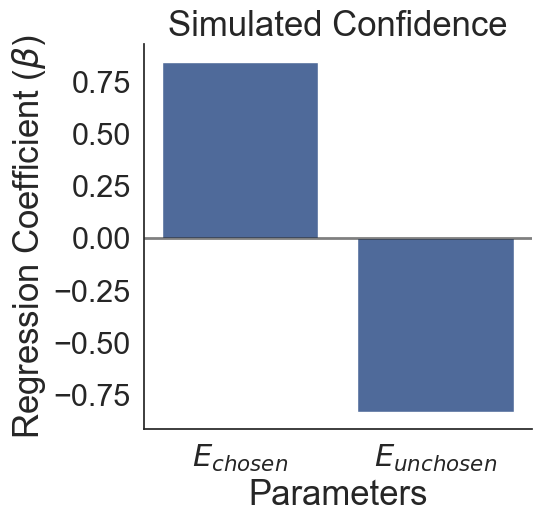

In [29]:
# Panel B: regression of confidence on chosen and unchosen evidence
print ('------------Simulations regression, conf -> chosen + unchosen ------------------ ')
ols_sims = sm.ols(formula="z_conf ~ z_energy_c + z_energy_u", data=posterior_df).fit()
print(ols_sims.summary())
regParam = ols_sims.params.values[1:]
lowLim = ols_sims.conf_int(alpha=0.05, cols=None)[0].values[1:]
highLim = ols_sims.conf_int(alpha=0.05, cols=None)[1].values[1:]

plt.errorbar(range(len(regParam)),regParam, yerr= np.abs(lowLim - highLim)/2 , color='#000000',marker='',fmt='.', alpha=0.8, markersize=8 , label = 'Simulations');
plt.bar(range(len(regParam)),regParam, yerr= np.abs(lowLim - highLim)/2 , color='#4F6A9A');

plt.axhline(0, color='black', lw=2, alpha=0.5)

font_size = 25
font_size_l = 22

plt.xlabel("Parameters",fontsize = font_size )
plt.ylabel("Regression Coefficient ($\\beta$)",fontsize = font_size)
plt.title('Simulated Confidence',fontsize = font_size)
plt.xticks([0,1],['$E_{chosen}$','$E_{unchosen}$'],fontsize = font_size_l)
plt.yticks(fontsize = font_size_l)
sns.despine()

plt.show()

------------Simulations regression, conf -> abs_d_energy + sum_energy ------------------ 
                            OLS Regression Results                            
Dep. Variable:                 z_conf   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                  1.000
Method:                 Least Squares   F-statistic:                 7.488e+33
Date:                Sat, 03 May 2025   Prob (F-statistic):               0.00
Time:                        21:23:56   Log-Likelihood:                 68255.
No. Observations:                2000   AIC:                        -1.365e+05
Df Residuals:                    1997   BIC:                        -1.365e+05
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------

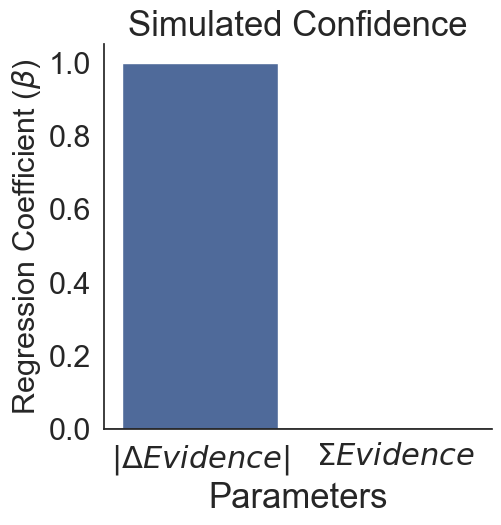

In [30]:
# Regression of confidence on |ΔEvidence| and ΣEvidence
print ('------------Simulations regression, conf -> abs_d_energy + sum_energy ------------------ ')
ols_sims = sm.ols(formula="z_conf ~ z_abs_d_energy + z_sum_energy", data=posterior_df).fit()
print(ols_sims.summary())
regParam = ols_sims.params.values[1:]
lowLim = ols_sims.conf_int(alpha=0.05, cols=None)[0].values[1:]
highLim = ols_sims.conf_int(alpha=0.05, cols=None)[1].values[1:]

plt.errorbar(range(len(regParam)),regParam, yerr= np.abs(lowLim - highLim)/2 , color='#000000',marker='',fmt='.', alpha=0.8, markersize=8 , label = 'Simulations');
plt.bar(range(len(regParam)),regParam, yerr= np.abs(lowLim - highLim)/2 , color='#4F6A9A');

plt.axhline(0, color='black', lw=2, alpha=0.5)

font_size = 25
font_size_l = 22

plt.xlabel("Parameters",fontsize = font_size)
plt.ylabel("Regression Coefficient ($\\beta$)",fontsize = font_size_l)
plt.title('Simulated Confidence',fontsize = font_size)
plt.xticks([0,1],[r'$|\Delta Evidence|$',r'$\Sigma Evidence$'],fontsize = font_size_l)
plt.yticks(fontsize = font_size_l)
sns.despine()

plt.show()

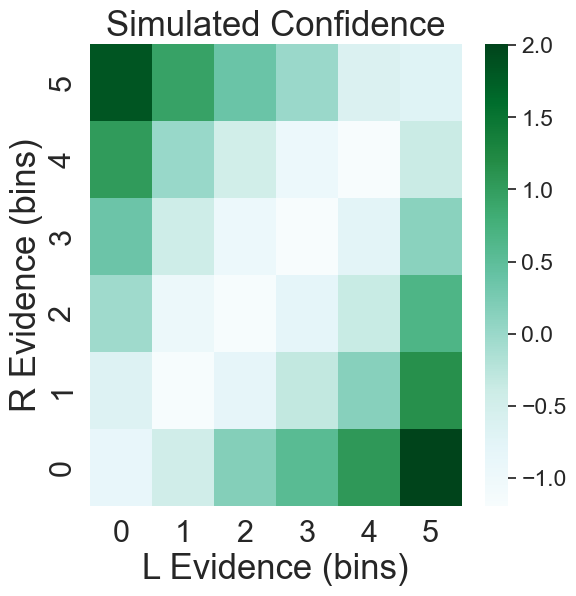

In [31]:
# Panel D: mean confidence over binned left / right evidence

bin_num = 6

df1 = pd.DataFrame()
df1['LVal_bin'] =pd.to_numeric(pd.qcut(posterior_df['energy_l'] , bin_num , labels=range(bin_num)))
df1['RVal_bin'] = pd.to_numeric(pd.qcut(posterior_df['energy_r'], bin_num , labels=range(bin_num)))
df1['conf'] = posterior_df['z_conf']

rowIDs = df1['LVal_bin']
colIDs = df1['RVal_bin']

# Create DV data
mat_2dim = np.zeros((rowIDs.max()+1,colIDs.max()+1))
mat_count = np.zeros((rowIDs.max()+1,colIDs.max()+1)) 
for i in range(len(df1)):
        x = int(df1.iloc[i].LVal_bin)
        y = int(df1.iloc[i].RVal_bin)
        mat_2dim[x][y] = mat_2dim[x][y] + df1.iloc[i].conf
        mat_count[x][y] = mat_count[x][y] + 1

mat_conf2D = np.zeros((rowIDs.max()+1,colIDs.max()+1))

for i in range(len(mat_2dim)):
    for j in range(len(mat_2dim[0])):
        mat_conf2D[i][j] = mat_2dim[i][j]/mat_count[i][j] 

plt.figure(figsize=(6,6))

ax = sns.heatmap(mat_conf2D,cmap="BuGn")
ax.invert_yaxis()
plt.xlabel('L Evidence (bins)',size=font_size)
plt.ylabel('R Evidence (bins)',size=font_size)
plt.title('Simulated Confidence',size=font_size)    
plt.yticks(fontsize = font_size_l)
plt.xticks(fontsize = font_size_l)

plt.show()

In [32]:
# Repeat the simulation 100 times and keep beta_chosen + beta_unchosen from each (used in panel C)
regsParams = []
for i in range(100):
 
    ppc = pm.sample_posterior_predictive(trace, model=model_peb1, var_names = ['choice','truDir','LLR','conf','lEnergy','rEnergy'])

    # Collect simulated trials: evidence, choice, confidence, chosen/unchosen evidence (z-scored for regressions)
    posterior_df = pd.DataFrame()

    posterior_df['choice'] = ppc.posterior_predictive['choice'].values[0]

    posterior_df['energy_l'] = ppc.posterior_predictive['lEnergy'].values[0]

    posterior_df['energy_r'] = ppc.posterior_predictive['rEnergy'].values[0]
    posterior_df['conf'] = ppc.posterior_predictive['conf'].values[0]
    posterior_df['truDir'] = ppc.posterior_predictive['truDir'].values[0]
    posterior_df['d_energy'] = ppc.posterior_predictive['rEnergy'].values[0] - ppc.posterior_predictive['lEnergy'].values[0]
    posterior_df['abs_d_energy'] = abs(ppc.posterior_predictive['rEnergy'].values[0] - ppc.posterior_predictive['lEnergy'].values[0])
    posterior_df['sum_energy'] = ppc.posterior_predictive['rEnergy'].values[0] + ppc.posterior_predictive['lEnergy'].values[0]
    posterior_df['correct'] = ppc.posterior_predictive['truDir'].values[0] == ppc.posterior_predictive['choice'].values[0]
    posterior_df['energy_c'] = posterior_df.apply(lambda row: row.energy_r if row.choice==1 else row.energy_l, axis=1)
    posterior_df['energy_u'] = posterior_df.apply(lambda row: row.energy_l if row.choice==1 else row.energy_r, axis=1)

    posterior_df['z_d_energy'] = z_score1(posterior_df,'d_energy')
    posterior_df['z_abs_d_energy'] = z_score1(posterior_df,'abs_d_energy')
    posterior_df['z_sum_energy'] = z_score1(posterior_df,'sum_energy')
    posterior_df['z_conf'] = z_score1(posterior_df,'conf')
    posterior_df['z_energy_c'] = z_score1(posterior_df,'energy_c')
    posterior_df['z_energy_u'] = z_score1(posterior_df,'energy_u')

    bin_num = 2
    # Median split of confidence
    posterior_df['conf_split'] =  pd.to_numeric(pd.qcut(posterior_df["z_conf"].values, bin_num , labels=range(bin_num)))

    ols_sims = sm.ols(formula="z_conf ~ z_energy_c + z_energy_u", data=posterior_df).fit()
    regParam = ols_sims.params.values[1:]
    lowLim = ols_sims.conf_int(alpha=0.05, cols=None)[0].values[1:]
    highLim = ols_sims.conf_int(alpha=0.05, cols=None)[1].values[1:]

    regsParams.append(regParam)

# add up all the values in each element of the list
sum_regParams_plus = np.sum(regsParams, axis=1)

## Low-evidence frame (choose the option with less evidence)

In [33]:
# Observer's belief distributions: means (low, high) and SDs (low, high)
mu = [0,1]
sigma = [1,1]

In [34]:
with pm.Model() as model_peb1:
    # Side with high evidence (0: left, 1: right)
    truDir = pm.Bernoulli("truDir", 0.5) 
    # Evidence for each option: mean 1 for the high-evidence side, 0 for the other (SD 1)
    lEnergy = pm.Normal('lEnergy', mu = 1 - truDir, sigma = 1)  # generative SD (not the observer's belief SD)
    rEnergy = pm.Normal('rEnergy', mu = truDir, sigma = 1)

    # Log-likelihood ratio that <right, left> = <high, low> under the observer's belief distributions (mu, sigma)
    LLR = pm.Deterministic('LLR',  pt.log(1/(sigma[1] * pt.sqrt(2 * np.pi))*pt.exp(-pt.power(rEnergy - mu[1] , 2.) / (2 * pt.power(sigma[1], 2.)))) - 
                                   pt.log(1/(sigma[0] * pt.sqrt(2 * np.pi))*pt.exp(-pt.power(rEnergy - mu[0] , 2.) / (2 * pt.power(sigma[0], 2.)))) + 
                                   pt.log(1/(sigma[0] * pt.sqrt(2 * np.pi))*pt.exp(-pt.power(lEnergy - mu[0] , 2.) / (2 * pt.power(sigma[0], 2.)))) -
                                   pt.log(1/(sigma[1] * pt.sqrt(2 * np.pi))*pt.exp(-pt.power(lEnergy - mu[1] , 2.) / (2 * pt.power(sigma[1], 2.))))  )
    
    # Low-evidence frame: choose right (1) if LLR <= 0
    cho = pm.math.switch(LLR<=0, 1, 0)
    choice = pm.Deterministic('choice',cho)
    
    # Confidence = |LLR|
    conf = pm.Deterministic('conf',abs(LLR))
    # Draw simulated trials from the generative model (no observed data)
    trace = pm.sample(2000, chains = 1)

Sequential sampling (1 chains in 1 job)
CompoundStep
>BinaryGibbsMetropolis: [truDir]
>NUTS: [lEnergy, rEnergy]


Sampling 1 chain for 1_000 tune and 2_000 draw iterations (1_000 + 2_000 draws total) took 3 seconds.


In [35]:
# Simulated trials (choice, confidence, evidence) from the sampled trace
ppc = pm.sample_posterior_predictive(trace, model=model_peb1, var_names = ['choice','truDir','LLR','conf','lEnergy','rEnergy'])

Sampling: [lEnergy, rEnergy, truDir]


In [36]:
# Collect simulated trials: evidence, choice, confidence, chosen/unchosen evidence (z-scored for regressions)
posterior_df = pd.DataFrame()
posterior_df['choice'] = ppc.posterior_predictive['choice'].values[0]
posterior_df['energy_l'] = ppc.posterior_predictive['lEnergy'].values[0]
posterior_df['energy_r'] = ppc.posterior_predictive['rEnergy'].values[0]
posterior_df['conf'] = ppc.posterior_predictive['conf'].values[0]
posterior_df['truDir'] = ppc.posterior_predictive['truDir'].values[0]
posterior_df['d_energy'] = ppc.posterior_predictive['rEnergy'].values[0] - ppc.posterior_predictive['lEnergy'].values[0]
posterior_df['abs_d_energy'] = abs(ppc.posterior_predictive['rEnergy'].values[0] - ppc.posterior_predictive['lEnergy'].values[0])
posterior_df['sum_energy'] = ppc.posterior_predictive['rEnergy'].values[0] + ppc.posterior_predictive['lEnergy'].values[0]
posterior_df['correct'] = ppc.posterior_predictive['truDir'].values[0] == ppc.posterior_predictive['choice'].values[0]
posterior_df['energy_c'] = posterior_df.apply(lambda row: row.energy_r if row.choice==1 else row.energy_l, axis=1)
posterior_df['energy_u'] = posterior_df.apply(lambda row: row.energy_l if row.choice==1 else row.energy_r, axis=1)

posterior_df['z_d_energy'] = z_score1(posterior_df,'d_energy')
posterior_df['z_abs_d_energy'] = z_score1(posterior_df,'abs_d_energy')
posterior_df['z_sum_energy'] = z_score1(posterior_df,'sum_energy')
posterior_df['z_conf'] = z_score1(posterior_df,'conf')
posterior_df['z_energy_c'] = z_score1(posterior_df,'energy_c')
posterior_df['z_energy_u'] = z_score1(posterior_df,'energy_u')

bin_num = 2
# Median split of confidence
posterior_df['conf_split'] =  pd.to_numeric(pd.qcut(posterior_df["z_conf"].values, bin_num , labels=range(bin_num)))

Low measure coef [[-126.92612313]]


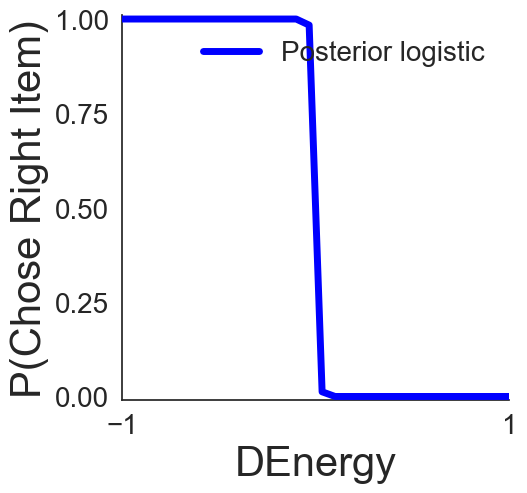

In [37]:
# P(choose right) as a function of ΔEvidence
fs.logisticplot_simpl ('Posterior logistic', posterior_df, xaxis='d_energy', yaxis='choice', ylab='P(Chose Right Item)', xlab='DEnergy',
                  modlowcol='blue', title='empty',xlim = [-1,1])

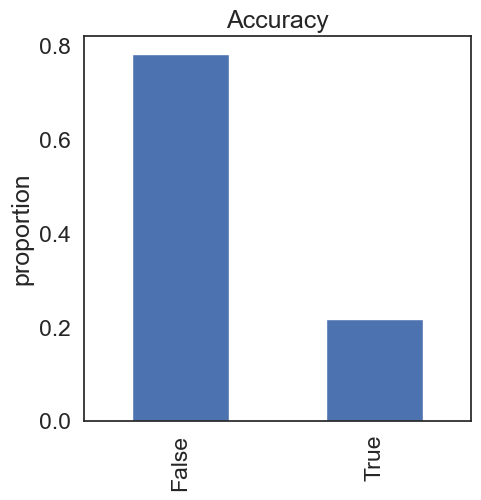

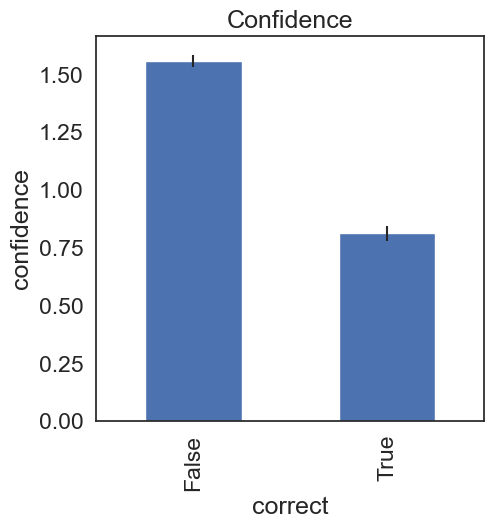

In [38]:
# Accuracy and confidence for correct vs error trials
posterior_df['correct'].value_counts(normalize=1,sort=0).plot(kind='bar',title='Accuracy')
plt.ylabel('proportion')
plt.show()

posterior_df.groupby('correct').mean()['conf'].plot(kind='bar',title='Confidence', 
                                                     yerr=posterior_df.groupby('correct').sem()['conf'])
plt.ylabel('confidence')
plt.show()

In [40]:
# Font sizes for the figures below
font_size = 22
font_size_l = 18

Correlation of confidence with chosen : -0.58 , p =  0.00 , unchosen :  0.59 , p =  0.00


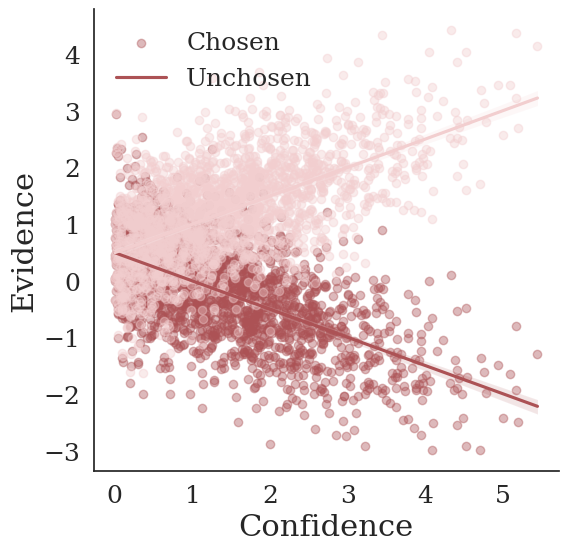

In [41]:
# Confidence vs chosen / unchosen evidence (Pearson correlations printed)
figsize(6, 6)

ax1 = sns.regplot(x="conf", y='energy_c',data=posterior_df,color='#AC5255',scatter_kws={'alpha':0.4})
sns.regplot(x="conf", y='energy_u',data=posterior_df,ax=ax1,color='#F2CECF',scatter_kws={'alpha':0.4})
plt.ylabel("Evidence",fontsize = font_size,)
plt.xlabel("Confidence",fontsize = font_size)
ax1.legend(labels=['Chosen', 'Unchosen'],fontsize = font_size_l,frameon = False)
plt.yticks(fontsize = font_size_l)
plt.xticks(fontsize = font_size_l)
sns.despine()

pcorr_cho = stats.pearsonr(posterior_df.conf.values, posterior_df.energy_c.values)
pcorr_uncho = stats.pearsonr(posterior_df.conf.values, posterior_df.energy_u.values)

print("Correlation of confidence with chosen : % .2f , p = % .2f , unchosen : % .2f , p = % .2f" %\
  (pcorr_cho[0],pcorr_cho[1],pcorr_uncho[0],pcorr_uncho[1])) 

Low measure coef [[-166.7299504]]
High measure coef [[-10.17840019]]


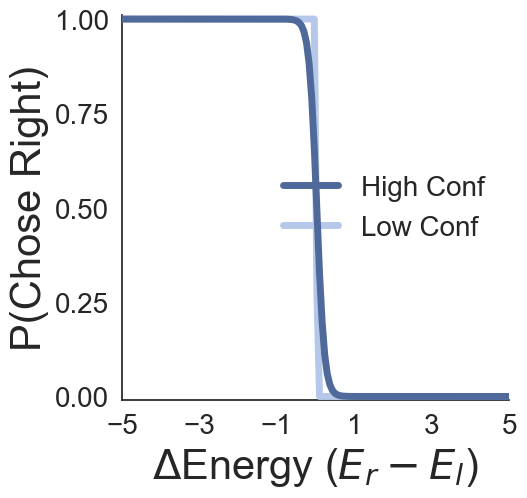

In [44]:
# Choice curves split by high / low confidence
fs.logisticplot_LowHigh ('conf_split', 'High Conf', 'Low Conf', posterior_df, xaxis='z_d_energy', yaxis='choice', ylab='P(Chose Right)', xlab='$\Delta$Energy ($E_{r}- E_{l}$)',
                 modhighcol='#4F6A9A', modlowcol='#B5C8E9', xlim = [-5,5])

Low measure coef [[-173.29949968]]


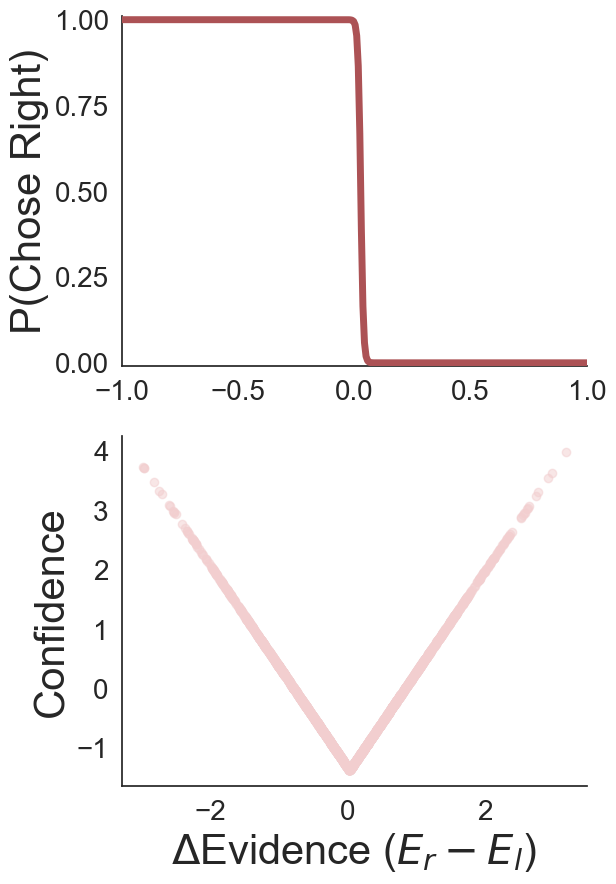

In [45]:
# Panel A: choice (top) and confidence (bottom) as a function of ΔEvidence
figModel, axModel = plt.subplots(figsize=(6, 10))

sub1 = plt.subplot(211)
fs.logisticplot_simpl_sims ('Posterior logistic', posterior_df, xaxis='z_d_energy', yaxis='choice', ylab='P(Chose Right)', xlab='',
                  modlowcol='#AC5255', title='empty',xlim = [-1,1],x_test_lim = 1, sub = sub1)
sub2 = plt.subplot(212)
sub2 = plt.scatter(posterior_df['z_d_energy'].values, posterior_df['z_conf'].values, c="#F2CECF", alpha=0.5,
            label="Model")
plt.tick_params(axis='both', which='major', labelsize=20)
plt.ylabel ('Confidence',size=30)
plt.xlabel( '$\Delta$Evidence ($E_{r}- E_{l}$)',size=30)

sns.despine()

------------Simulations regression, conf -> chosen + unchosen ------------------ 
                            OLS Regression Results                            
Dep. Variable:                 z_conf   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                  1.000
Method:                 Least Squares   F-statistic:                 4.584e+33
Date:                Sat, 03 May 2025   Prob (F-statistic):               0.00
Time:                        21:24:50   Log-Likelihood:                 67764.
No. Observations:                2000   AIC:                        -1.355e+05
Df Residuals:                    1997   BIC:                        -1.355e+05
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------

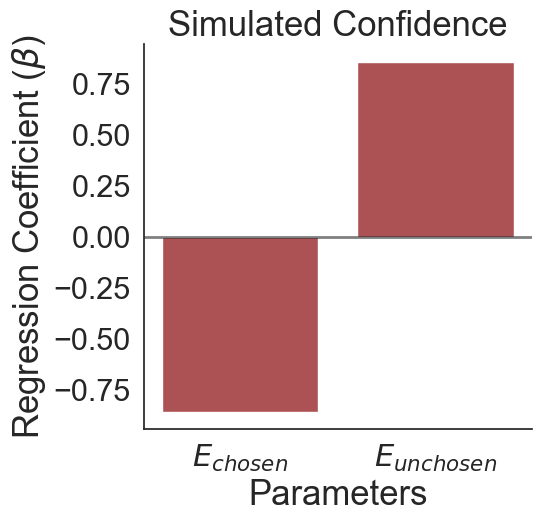

In [46]:
# Panel B: regression of confidence on chosen and unchosen evidence
print ('------------Simulations regression, conf -> chosen + unchosen ------------------ ')
ols_sims = sm.ols(formula="z_conf ~ z_energy_c + z_energy_u", data=posterior_df).fit()
print(ols_sims.summary())
regParam = ols_sims.params.values[1:]
lowLim = ols_sims.conf_int(alpha=0.05, cols=None)[0].values[1:]
highLim = ols_sims.conf_int(alpha=0.05, cols=None)[1].values[1:]

plt.errorbar(range(len(regParam)),regParam, yerr= np.abs(lowLim - highLim)/2 , color='#000000',marker='',fmt='.', alpha=0.8, markersize=8 , label = 'Simulations');
plt.bar(range(len(regParam)),regParam, yerr= np.abs(lowLim - highLim)/2 , color='#AC5255');

plt.axhline(0, color='black', lw=2, alpha=0.5)

font_size = 25
font_size_l = 22

plt.xlabel("Parameters",fontsize = font_size )
plt.ylabel("Regression Coefficient ($\\beta$)",fontsize = font_size)
plt.title('Simulated Confidence',fontsize = font_size)
plt.xticks([0,1],['$E_{chosen}$','$E_{unchosen}$'],fontsize = font_size_l)
plt.yticks(fontsize = font_size_l)
sns.despine()

plt.show()

------------Simulations regression, conf -> abs_d_energy + sum_energy ------------------ 
                            OLS Regression Results                            
Dep. Variable:                 z_conf   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                  1.000
Method:                 Least Squares   F-statistic:                 3.104e+33
Date:                Sat, 03 May 2025   Prob (F-statistic):               0.00
Time:                        21:24:50   Log-Likelihood:                 67374.
No. Observations:                2000   AIC:                        -1.347e+05
Df Residuals:                    1997   BIC:                        -1.347e+05
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------

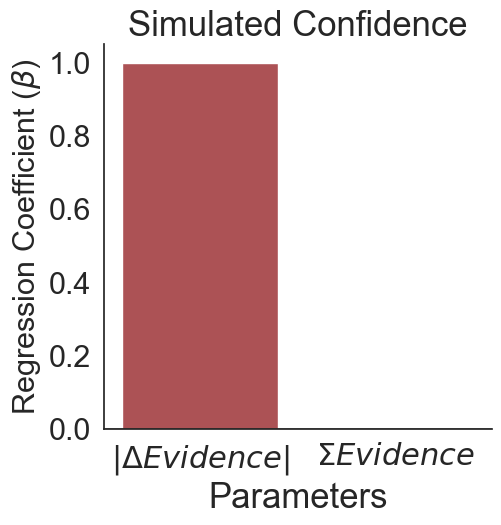

In [47]:
# Regression of confidence on |ΔEvidence| and ΣEvidence
print ('------------Simulations regression, conf -> abs_d_energy + sum_energy ------------------ ')
ols_sims = sm.ols(formula="z_conf ~ z_abs_d_energy + z_sum_energy", data=posterior_df).fit()
print(ols_sims.summary())
regParam = ols_sims.params.values[1:]
lowLim = ols_sims.conf_int(alpha=0.05, cols=None)[0].values[1:]
highLim = ols_sims.conf_int(alpha=0.05, cols=None)[1].values[1:]

plt.errorbar(range(len(regParam)),regParam, yerr= np.abs(lowLim - highLim)/2 , color='#000000',marker='',fmt='.', alpha=0.8, markersize=8 , label = 'Simulations');
plt.bar(range(len(regParam)),regParam, yerr= np.abs(lowLim - highLim)/2 , color='#AC5255');

plt.axhline(0, color='black', lw=2, alpha=0.5)

font_size = 25
font_size_l = 22

plt.xlabel("Parameters",fontsize = font_size)
plt.ylabel("Regression Coefficient ($\\beta$)",fontsize = font_size_l)
plt.title('Simulated Confidence',fontsize = font_size)
plt.xticks([0,1],[r'$|\Delta Evidence|$',r'$\Sigma Evidence$'],fontsize = font_size_l)
plt.yticks(fontsize = font_size_l)
sns.despine()

plt.show()

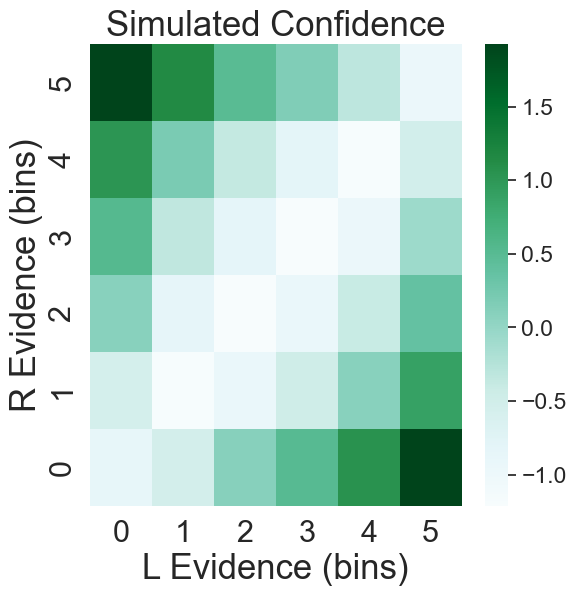

In [48]:
# Panel D: mean confidence over binned left / right evidence

bin_num = 6

df1 = pd.DataFrame()
df1['LVal_bin'] =pd.to_numeric(pd.qcut(posterior_df['energy_l'] , bin_num , labels=range(bin_num)))
df1['RVal_bin'] = pd.to_numeric(pd.qcut(posterior_df['energy_r'], bin_num , labels=range(bin_num)))
df1['conf'] = posterior_df['z_conf']

rowIDs = df1['LVal_bin']
colIDs = df1['RVal_bin']

# Create DV data
mat_2dim = np.zeros((rowIDs.max()+1,colIDs.max()+1))
mat_count = np.zeros((rowIDs.max()+1,colIDs.max()+1)) 
for i in range(len(df1)):
        x = int(df1.iloc[i].LVal_bin)
        y = int(df1.iloc[i].RVal_bin)
        mat_2dim[x][y] = mat_2dim[x][y] + df1.iloc[i].conf
        mat_count[x][y] = mat_count[x][y] + 1

mat_conf2D = np.zeros((rowIDs.max()+1,colIDs.max()+1))

for i in range(len(mat_2dim)):
    for j in range(len(mat_2dim[0])):
        mat_conf2D[i][j] = mat_2dim[i][j]/mat_count[i][j] 

plt.figure(figsize=(6,6))

ax = sns.heatmap(mat_conf2D,cmap="BuGn")
ax.invert_yaxis()
plt.xlabel('L Evidence (bins)',size=font_size)
plt.ylabel('R Evidence (bins)',size=font_size)
plt.title('Simulated Confidence',size=font_size)    
plt.yticks(fontsize = font_size_l)
plt.xticks(fontsize = font_size_l)

plt.show()

In [49]:
# Repeat the simulation 100 times and keep beta_chosen + beta_unchosen from each (used in panel C)
regsParams = []
for i in range(100):
 
    ppc = pm.sample_posterior_predictive(trace, model=model_peb1, var_names = ['choice','truDir','LLR','conf','lEnergy','rEnergy'])

    # Collect simulated trials: evidence, choice, confidence, chosen/unchosen evidence (z-scored for regressions)
    posterior_df = pd.DataFrame()

    posterior_df['choice'] = ppc.posterior_predictive['choice'].values[0]

    posterior_df['energy_l'] = ppc.posterior_predictive['lEnergy'].values[0]

    posterior_df['energy_r'] = ppc.posterior_predictive['rEnergy'].values[0]
    posterior_df['conf'] = ppc.posterior_predictive['conf'].values[0]
    posterior_df['truDir'] = ppc.posterior_predictive['truDir'].values[0]
    posterior_df['d_energy'] = ppc.posterior_predictive['rEnergy'].values[0] - ppc.posterior_predictive['lEnergy'].values[0]
    posterior_df['abs_d_energy'] = abs(ppc.posterior_predictive['rEnergy'].values[0] - ppc.posterior_predictive['lEnergy'].values[0])
    posterior_df['sum_energy'] = ppc.posterior_predictive['rEnergy'].values[0] + ppc.posterior_predictive['lEnergy'].values[0]
    posterior_df['correct'] = ppc.posterior_predictive['truDir'].values[0] == ppc.posterior_predictive['choice'].values[0]
    posterior_df['energy_c'] = posterior_df.apply(lambda row: row.energy_r if row.choice==1 else row.energy_l, axis=1)
    posterior_df['energy_u'] = posterior_df.apply(lambda row: row.energy_l if row.choice==1 else row.energy_r, axis=1)

    posterior_df['z_d_energy'] = z_score1(posterior_df,'d_energy')
    posterior_df['z_abs_d_energy'] = z_score1(posterior_df,'abs_d_energy')
    posterior_df['z_sum_energy'] = z_score1(posterior_df,'sum_energy')
    posterior_df['z_conf'] = z_score1(posterior_df,'conf')
    posterior_df['z_energy_c'] = z_score1(posterior_df,'energy_c')
    posterior_df['z_energy_u'] = z_score1(posterior_df,'energy_u')

    bin_num = 2
    # Median split of confidence
    posterior_df['conf_split'] =  pd.to_numeric(pd.qcut(posterior_df["z_conf"].values, bin_num , labels=range(bin_num)))

    ols_sims = sm.ols(formula="z_conf ~ z_energy_c + z_energy_u", data=posterior_df).fit()
    regParam = ols_sims.params.values[1:]
    lowLim = ols_sims.conf_int(alpha=0.05, cols=None)[0].values[1:]
    highLim = ols_sims.conf_int(alpha=0.05, cols=None)[1].values[1:]

    regsParams.append(regParam)

# add up all the values in each element of the list
sum_regParams_minus = np.sum(regsParams, axis=1)

## Panel C: overall evidence effect in both frames

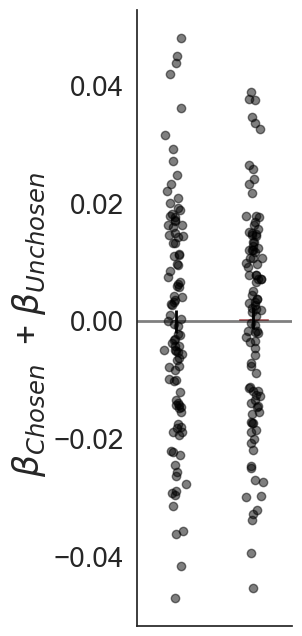

Overall effect (+)4.829664626301966e-05STE: 0.001958758301056703
Overall effect (-)0.0005731097413561293STE: 0.0018055798537672963


In [52]:
# Panel C: beta_chosen + beta_unchosen in the high- (blue) and low-evidence (red) frames, one-sample t-tests against 0
barcol1='#4F6A9A'
barcol2='#AC5255'
fig2 = plt.figure(figsize=[2,8])

ax2 = fig2.add_subplot()    

bChoMinusUncho_1 = sum_regParams_plus
bChoMinusUncho_2 = sum_regParams_minus

ax2.bar(1, np.mean(bChoMinusUncho_1), width=0.4,color=barcol1)
ax2.errorbar(1, np.mean(bChoMinusUncho_1),
            yerr= stats.sem(bChoMinusUncho_1), lw=2, color='#000000')

ax2.bar(2, np.mean(bChoMinusUncho_2), width=0.4,color=barcol2)
ax2.errorbar(2, np.mean(bChoMinusUncho_2),
            yerr= stats.sem(bChoMinusUncho_2), lw=2, color='#000000')

# add scatter points , include some jitter in the x-axis
x1 = np.random.normal(1, 0.05, len(bChoMinusUncho_1))
x2 = np.random.normal(2, 0.05, len(bChoMinusUncho_2))
ax2.plot(x1, bChoMinusUncho_1, 'o', color='black', alpha=0.5)
ax2.plot(x2, bChoMinusUncho_2, 'o', color='black', alpha=0.5)

ax2.set_ylabel('$\\beta_{Chosen}$  + $\\beta_{Unchosen}$  ', fontsize=25)

ax2.set_xticks([])        

ax2.tick_params(axis='y', labelsize= 20 )    
#horizontal line
ax2.axhline(0, color='black', lw=2, alpha=0.5)
ax2.set_xlim(0.5,2.5)

# t-test one sample different from 0
[s, p] = stats.ttest_1samp(bChoMinusUncho_1, 0)
    # add star is significant
if p < 0.05:
    start_text = "*"
elif p < 0.01:
    start_text = "**"
elif p < 0.001:
    start_text = "***"
else:
    start_text = ""
# Determine max height and x position for annotation
max_height = max(bChoMinusUncho_1) + 0.001  # Maximum bar height
mid_x = 1  # Middle x position
# Draw significance marker
plt.text(mid_x, max_height , start_text, fontsize=35, ha="center")  # Significance star

# t-test one sample different from 0
[s, p] = stats.ttest_1samp(bChoMinusUncho_2, 0)
    # add star is significant
if p < 0.05:
    start_text = "*"
elif p < 0.01:
    start_text = "**"
elif p < 0.001:
    start_text = "***"
else:
    start_text = ""
# Determine max height and x position for annotation
mid_x = 2  # Middle x position
# Draw significance marker
plt.text(mid_x, max_height , start_text, fontsize=35, ha="center")  # Significance star

sns.despine()
plt.show()

print('Overall effect (+)' + str(np.mean(bChoMinusUncho_1)) + 'STE: '+ str( np.std(bChoMinusUncho_1)/np.sqrt(len(bChoMinusUncho_1))))
print('Overall effect (-)' + str(np.mean(bChoMinusUncho_2))  + 'STE: '+ str( np.std(bChoMinusUncho_2)/np.sqrt(len(bChoMinusUncho_2))))

In [54]:
# run t-tesst for bChoMinusUncho_1 
print('T-test for Pos:')
[s, p] = stats.ttest_1samp(bChoMinusUncho_1, 0)
print(f"t-statistic: {s}, p-value: {p}")
# run t-tesst for bChoMinusUncho_2
print('T-test for Neg:')
[s, p] = stats.ttest_1samp(bChoMinusUncho_2, 0)
print(f"t-statistic: {s}, p-value: {p}")

T-test for Pos:
t-statistic: 0.024533173010760266, p-value: 0.9804767059717941
T-test for Neg:
t-statistic: 0.3158193150765323, p-value: 0.7528044952609148
